# Data Exploration: LIAR Binary Credibility MVP

This notebook downloads the LIAR dataset, converts the six-class labels into a binary credibility target, and produces exploratory analysis artifacts for the MVP.

Important scope note: this work predicts credibility of short LIAR-style claims, not full articles and not real-time factual truth.

In [1]:
from pathlib import Path
import zipfile

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

LIAR_ZIP_URL = "https://www.cs.ucsb.edu/~william/data/liar_dataset.zip"
PROJECT_ROOT = Path(".").resolve()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

for path in [RAW_DIR, INTERIM_DIR, PROCESSED_DIR, REPORTS_FIGURES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_colwidth", 200)


## Download and Extract LIAR

In [2]:
zip_path = RAW_DIR / "liar_dataset.zip"

if not zip_path.exists():
    response = requests.get(LIAR_ZIP_URL, timeout=60)
    response.raise_for_status()
    zip_path.write_bytes(response.content)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(INTERIM_DIR)

sorted([p.name for p in INTERIM_DIR.glob("*.tsv")])

['test.tsv', 'train.tsv', 'valid.tsv']

## Load Split Files with Explicit Schema

In [3]:
columns = [
    "statement_id",
    "original_label",
    "statement",
    "subject",
    "speaker",
    "speaker_job",
    "state_info",
    "party_affiliation",
    "barely_true_counts",
    "false_counts",
    "half_true_counts",
    "mostly_true_counts",
    "pants_on_fire_counts",
    "context",
]

train_df = pd.read_csv(INTERIM_DIR / "train.tsv", sep="\t", header=None, names=columns)
valid_df = pd.read_csv(INTERIM_DIR / "valid.tsv", sep="\t", header=None, names=columns)
test_df = pd.read_csv(INTERIM_DIR / "test.tsv", sep="\t", header=None, names=columns)

train_df["split"] = "train"
valid_df["split"] = "valid"
test_df["split"] = "test"

df = pd.concat([train_df, valid_df, test_df], ignore_index=True)
df.shape

(12791, 15)

## Binary Mapping

The ambiguous `half-true` label is dropped in the main experiment to create a cleaner binary task:

- `0 = not_credible` (`pants-fire`, `false`, `barely-true`)
- `1 = credible` (`mostly-true`, `true`)

In [4]:
label_map = {
    "pants-fire": 0,
    "false": 0,
    "barely-true": 0,
    "mostly-true": 1,
    "true": 1,
}

name_map = {
    0: "not_credible",
    1: "credible",
}

df_binary = df[df["original_label"].isin(label_map)].copy()
df_binary["label"] = df_binary["original_label"].map(label_map)
df_binary["label_name"] = df_binary["label"].map(name_map)

df_binary.shape

(10164, 17)

In [5]:
df_binary["text_length_chars"] = df_binary["statement"].fillna("").str.len()
df_binary["text_length_words"] = df_binary["statement"].fillna("").str.split().str.len()

In [6]:
processed_columns = [
    "split",
    "statement_id",
    "original_label",
    "label",
    "label_name",
    "statement",
    "subject",
    "speaker",
    "speaker_job",
    "state_info",
    "party_affiliation",
    "context",
    "text_length_chars",
    "text_length_words",
]

df_binary = df_binary[processed_columns]

assert set(df_binary["split"].unique()) == {"train", "valid", "test"}
assert set(df_binary["label"].unique()) == {0, 1}
assert "half-true" not in set(df_binary["original_label"].unique())
assert df_binary["statement"].notna().all()

In [7]:
processed_path = PROCESSED_DIR / "liar_binary.csv"
df_binary.to_csv(processed_path, index=False)
processed_path

PosixPath('/Users/marcinmalek/Documents/Codes/Projects/WORK/news-credibility/data/processed/liar_binary.csv')

## Row Counts Before and After Binary Filtering

In [8]:
row_count_summary = pd.DataFrame({
    "stage": ["original_liar", "binary_without_half_true"],
    "rows": [len(df), len(df_binary)],
})
row_count_summary

,stage,rows
0,original_liar,12791
1,binary_without_half_true,10164


The binary conversion removes `half-true` statements to reduce class ambiguity in the MVP baseline.

## Class Distribution

In [9]:
class_counts = (
    df_binary["label_name"]
    .value_counts()
    .rename_axis("label_name")
    .reset_index(name="rows")
)
class_counts

,label_name,rows
0,not_credible,5657
1,credible,4507


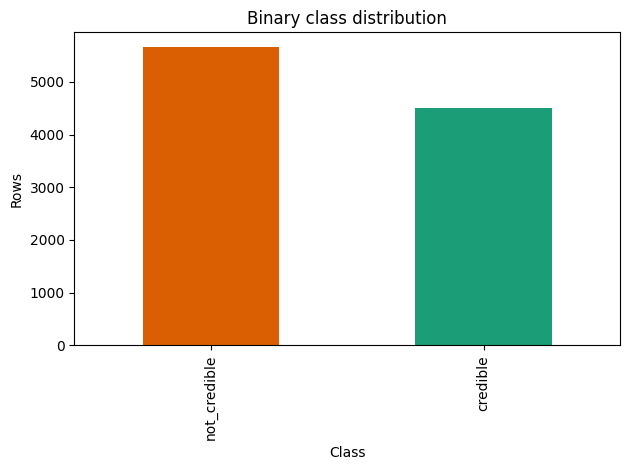

In [10]:
ax = class_counts.plot(kind="bar", x="label_name", y="rows", legend=False, color=["#d95f02", "#1b9e77"])
ax.set_title("Binary class distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Rows")
plt.tight_layout()
plt.savefig(REPORTS_FIGURES_DIR / "class_distribution.png", dpi=150)
plt.show()

## Split Distribution

In [11]:
split_counts = (
    df_binary["split"]
    .value_counts()
    .rename_axis("split")
    .reset_index(name="rows")
)
split_counts

,split,rows
0,train,8126
1,valid,1036
2,test,1002


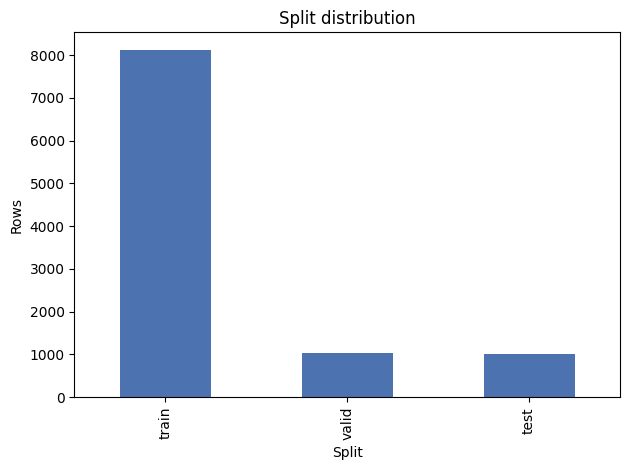

In [12]:
ax = split_counts.plot(kind="bar", x="split", y="rows", legend=False, color="#4c72b0")
ax.set_title("Split distribution")
ax.set_xlabel("Split")
ax.set_ylabel("Rows")
plt.tight_layout()
plt.savefig(REPORTS_FIGURES_DIR / "split_distribution.png", dpi=150)
plt.show()

## Text Length by Class

In [13]:
df_binary.groupby("label_name")[["text_length_chars", "text_length_words"]].agg(["mean", "median", "min", "max"])

text_length_chars                  text_length_words             \
                          mean median min   max              mean median min   
label_name                                                                     
credible            107.824051   99.0  11  3192         18.288884   17.0   2   
not_credible        104.044193   95.0  11  2099         17.416475   16.0   2   

                   
              max  
label_name         
credible      467  
not_credible  309

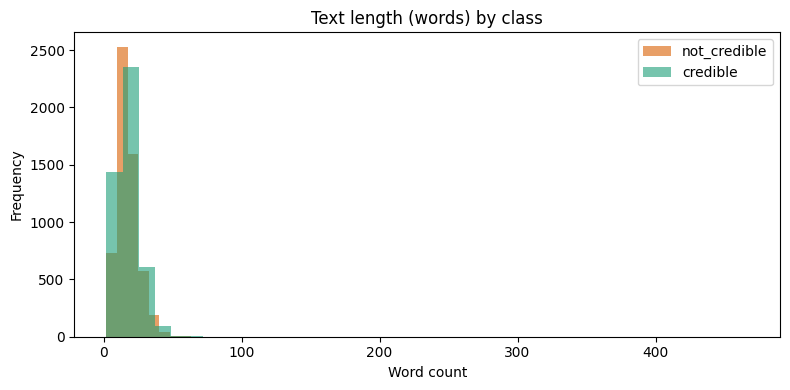

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
for label_name, color in [("not_credible", "#d95f02"), ("credible", "#1b9e77")]:
    subset = df_binary[df_binary["label_name"] == label_name]["text_length_words"]
    ax.hist(subset, bins=40, alpha=0.6, label=label_name, color=color)
ax.set_title("Text length (words) by class")
ax.set_xlabel("Word count")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS_FIGURES_DIR / "text_length_by_class.png", dpi=150)
plt.show()

## Top Subject Categories

In [15]:
top_subjects = df_binary["subject"].fillna("missing").value_counts().head(15)
top_subjects

subject
health-care             378
taxes                   281
elections               261
education               241
immigration             240
candidates-biography    211
economy                 129
guns                    121
federal-budget          114
economy,jobs            111
abortion                 93
jobs                     92
energy                   91
foreign-policy           88
state-budget             86
Name: count, dtype: int64

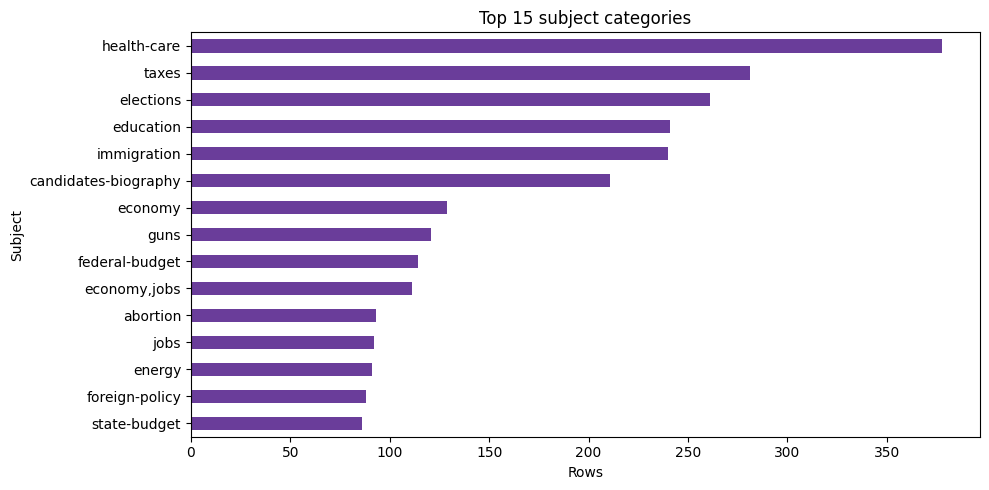

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
top_subjects.sort_values().plot(kind="barh", ax=ax, color="#6a3d9a")
ax.set_title("Top 15 subject categories")
ax.set_xlabel("Rows")
ax.set_ylabel("Subject")
plt.tight_layout()
plt.savefig(REPORTS_FIGURES_DIR / "top_subjects.png", dpi=150)
plt.show()

## Missing Value Summary

In [17]:
missing_summary = (
    df_binary.isna()
    .sum()
    .sort_values(ascending=False)
    .rename("missing_count")
    .reset_index()
    .rename(columns={"index": "column"})
)
missing_summary

,column,missing_count
0,speaker_job,2854
1,state_info,2215
2,context,108
3,subject,2
4,speaker,2
5,party_affiliation,2
6,split,0
7,statement_id,0
8,original_label,0
9,label,0


Missingness exists mostly in metadata fields (for example `speaker_job`, `state_info`, `party_affiliation`). The core text-only modeling path relies on `statement`, so this does not block the main baselines.

## Example Statements From Both Classes

In [18]:
for label_name in ["not_credible", "credible"]:
    print(f"\nExamples for {label_name}:")
    display(
        df_binary[df_binary["label_name"] == label_name][
            ["original_label", "label_name", "statement", "subject", "speaker"]
        ].sample(5, random_state=42)
    )


Examples for not_credible:


,original_label,label_name,statement,subject,speaker
9054,barely-true,not_credible,Says Wisconsin Supreme Court Justice David Prosser has prejudged matters that are likely to come before the court.,legal-issues,joanne-kloppenburg
11509,false,not_credible,We've excluded lobbyists from policymaking jobs.,ethics,barack-obama
8477,barely-true,not_credible,"3,000 teachers lost their jobs when (Crist) was governor.","economy,education,stimulus",rick-scott
3363,barely-true,not_credible,Says North Carolina Republican Senate candidate Thom Tillis called Obamacare a great idea.,health-care,kay-hagan
11765,barely-true,not_credible,"Says in 2003 Texas cut $10 billion out of the entire budget, yet we put $1.8 billion more into public education. We put $800 million more into health and human services.",state-budget,rick-perry



Examples for credible:


,original_label,label_name,statement,subject,speaker
2084,mostly-true,credible,"Republican candidate for governor Allan Fung donated to Democrats like Congressman David Cicilline, disgraced (House) speaker Gordon Fox and even Mr. Obamacare, Harry Reid.","bipartisanship,campaign-finance,candidates-biography,debates",kenneth-block
3570,mostly-true,credible,"Since 2009, after-tax incomes are up nearly 14 percent.",economy,penny-pritzker
6154,true,credible,A couple of hundred American cities are infested by members of the Mexican cartels.,"crime,drugs,homeland-security",michael-cutler
2614,true,credible,"Obama spent ""40 percent of the PAC money, 43 percent to be exact, on Iowa, New Hampshire, Nevada and South Carolina politicians.""",ethics,bill-clinton
7697,true,credible,Says David Jolly refused to cut spending for a national greenhouse in D.C.,federal-budget,club-growth


In [19]:
df_binary.head()

,split,statement_id,original_label,label,label_name,statement,subject,speaker,speaker_job,state_info,party_affiliation,context,text_length_chars,text_length_words
0,train,2635.json,false,0,not_credible,Says the Annies List political group supports third-trimester abortions on demand.,abortion,dwayne-bohac,State representative,Texas,republican,a mailer,82,11
2,train,324.json,mostly-true,1,credible,"Hillary Clinton agrees with John McCain ""by voting to give George Bush the benefit of the doubt on Iran.""",foreign-policy,barack-obama,President,Illinois,democrat,Denver,105,19
3,train,1123.json,false,0,not_credible,Health care reform legislation is likely to mandate free sex change surgeries.,health-care,blog-posting,NaN,NaN,none,a news release,78,12
5,train,12465.json,true,1,credible,The Chicago Bears have had more starting quarterbacks in the last 10 years than the total number of tenured (UW) faculty fired during the last two decades.,education,robin-vos,Wisconsin Assembly speaker,Wisconsin,republican,a an online opinion-piece,155,27
6,train,2342.json,barely-true,0,not_credible,Jim Dunnam has not lived in the district he represents for years now.,candidates-biography,republican-party-texas,NaN,Texas,republican,a press release.,69,13
